# Advanced Chemical Reaction Engieering (CBE 60546)
## Homework 2
## Due September 12, 2025

Carefully and neatly document your answers. You may use a mathematical solver like Jupyter/iPython. Use plotting software for all plots.

# Shale, shale everywhere
## Your nation has stumbled upon an enormous reserver of ethane (that's really true!), which you propose to use as a feedstock to produce ethylene, acetylene, and hydrogen via thermal dehydrogenation:
$\ce{C2H6(g) -> C2H4(g) + H2(g)}$ \
$\ce{C2H6(g) -> C2H2(g) + 2H2(g)}$

## The thermodynamic data [here](https://github.com/wmfschneider/CBE60546/blob/main/Homework/HW2-thermo.csv) is from the [CRC Handbook](https://onesearch.library.nd.edu/permalink/f/1phik6l/ndu_aleph002720619), and is based on 1 bar standard state. All the gases can be considered to be ideal over the range of interest here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from scipy.optimize import root
from scipy.optimize import curve_fit
# from google.colab import files # This is required only when you are using Colab.

### What does CSV stand for?

- **CSV** stands for **Comma-Separated Values**.  
- It is a simple text file format where each line corresponds to a row of data, and values in each row are separated by commas.  

### Why is the `pandas` package good for reading CSV files?

- The `pandas` library in Python provides the powerful function `pd.read_csv()` that can:
- Load CSV data directly into a **DataFrame** (a 2D table-like structure with labeled rows and columns).
- Automatically parse headers (column names).
- Handle missing values gracefully.
- Read large files efficiently, with options for chunking.
- Support advanced features like specifying delimiters (`,`, `;`, `\t`), selecting only certain columns, parsing dates, etc.

In [2]:
# Upload HW2-thermo.csv with colab.files, read it and store it as a Pandas dataframe.
# If you use Jupyter on you own laptop, you don't need to upload the file.
df = pd.read_csv("HW2-thermo.csv")
df.head() # This displays top 5 rows

,Row,Subheader,T (K),Cp° (J/mol K),S° (J/mol K),-(G°-H°(T)) (J/mol K),(H-H°(T)) (kJ/mo),∆Hf° (kJ/mol),∆Gf° (kJ/mol),Log Kf
0,156,12. ACETYLENE C<sub>2</sub>H<sub>2</sub> (g),298.15,44.036,200.927,200.927,0.000,227.400,209.879,-36.769
1,157,12. ACETYLENE C<sub>2</sub>H<sub>2</sub> (g),300.00,44.174,201.199,200.927,0.082,227.397,209.770,-36.524
2,158,12. ACETYLENE C<sub>2</sub>H<sub>2</sub> (g),400.00,50.388,214.814,202.741,4.829,227.161,203.928,-26.630
3,159,12. ACETYLENE C<sub>2</sub>H<sub>2</sub> (g),500.00,54.751,226.552,206.357,10.097,226.846,198.154,-20.701
4,160,12. ACETYLENE C<sub>2</sub>H<sub>2</sub> (g),600.00,58.121,236.842,210.598,15.747,226.445,192.452,-16.754


In [3]:
df.tail() # This displays bottom 5 rows

,Row,Subheader,T (K),Cp° (J/mol K),S° (J/mol K),-(G°-H°(T)) (J/mol K),(H-H°(T)) (kJ/mo),∆Hf° (kJ/mol),∆Gf° (kJ/mol),Log Kf
51,702,51. DIHYDROGEN H<sub>2</sub> (g),1100.0,30.580,169.113,147.550,23.719,0.0,0.0,0.0
52,703,51. DIHYDROGEN H<sub>2</sub> (g),1200.0,30.991,171.791,149.460,26.797,0.0,0.0,0.0
53,704,51. DIHYDROGEN H<sub>2</sub> (g),1300.0,31.422,174.288,151.275,29.918,0.0,0.0,0.0
54,705,51. DIHYDROGEN H<sub>2</sub> (g),1400.0,31.860,176.633,153.003,33.082,0.0,0.0,0.0
55,706,51. DIHYDROGEN H<sub>2</sub> (g),1500.0,32.296,178.846,154.653,36.290,0.0,0.0,0.0


### Q1.1. Plot the standard state enthalpy of ethane vs $T$ from 600 to 1200 K. What does the slope of the plot correspond to? 

    Row                                  Subheader   T (K)  Cp° (J/mol K)  \
32  188  14. ETHANE C<sub>2</sub>H<sub>6</sub> (g)   600.0         89.188   
33  189  14. ETHANE C<sub>2</sub>H<sub>6</sub> (g)   700.0         99.136   
34  190  14. ETHANE C<sub>2</sub>H<sub>6</sub> (g)   800.0        107.936   
35  191  14. ETHANE C<sub>2</sub>H<sub>6</sub> (g)   900.0        115.709   
36  192  14. ETHANE C<sub>2</sub>H<sub>6</sub> (g)  1000.0        122.552   

    S° (J/mol K)  -(G°-H°(T)) (J/mol K)  (H-H°(T)) (kJ/mo)  ∆Hf° (kJ/mol)  \
32       277.568                241.660             21.545        -96.779   
33       292.080                247.835             30.972        -99.663   
34       305.904                254.236             41.334       -101.963   
35       319.075                260.715             52.525       -103.754   
36       331.628                267.183             64.445       -105.105   

    ∆Gf° (kJ/mol)  Log Kf  
32         26.086  -2.271  
33         46.800 

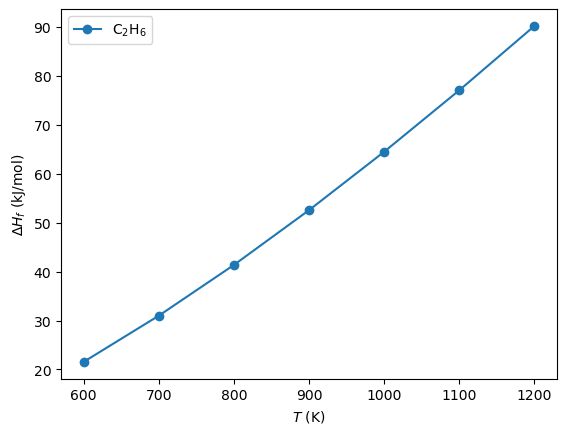

In [4]:
# Find and search indexes for ETHANE data by name in 'Subheader' column
idx = np.where(df.Subheader.str.contains("ETHANE", case=False, na=False))[0]
df_ethane = df.iloc[idx[0]:idx[-1]]
# Filter data by temperature range
df_ethane = df_ethane[(df_ethane['T (K)'] >= 600) & (df_ethane['T (K)'] <= 1200)]
# Show top 5 rows for ETHANE data
print(df_ethane.head())
# Standard state enthalpy of ethane corresponds to '(H-H°(T)) (kJ/mo)' not '∆Hf° (kJ/mol)'
plt.plot(df_ethane['T (K)'], df_ethane['(H-H°(T)) (kJ/mo)'], 'o-', label = 'C$_2$H$_6$')
plt.legend()
plt.xlabel('$T$ (K)')
plt.ylabel(r'∆$H_f$ (kJ/mol)')
plt.show()

### Q1.2. Is the slope positive or negative? Why?

For the “standard enthalpy” you plotted as the sensible enthalpy, $H(T) - H^\circ(298\ \mathrm{K})$,

$$
H(T) - H^\circ(298) = \int_{298}^{T} C_p(T') \, dT'
$$

so the slope of the curve is

$$
\frac{d}{dT}\left[ H(T) - H^\circ(298) \right] = C_p(T).
$$ 

Therefore, the plot has a **positive slope**, and its numerical value at any $T$ equals the molar heat capacity $C_p(T)$ (in kJ mol⁻¹ K⁻¹).

### Q1.3. Plot the standard state entropy of ethane vs $T$ from 600 to 1200 K. 

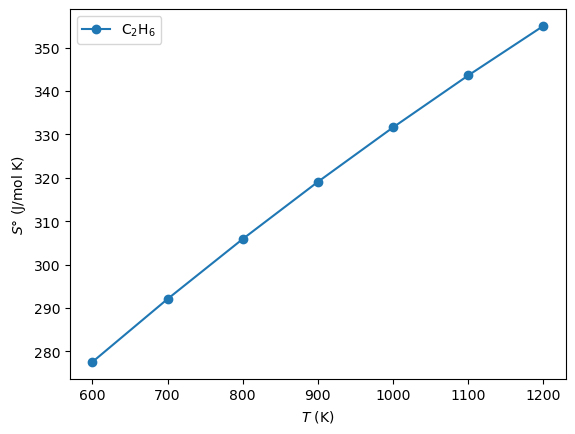

The slope corresponds to Cv/T.


In [5]:
# Answer here
plt.plot(df_ethane['T (K)'], df_ethane['S° (J/mol K)'], 'o-', label = 'C$_2$H$_6$')
# plt.xlim(600,1200)
# plt.ylim(275,360)
plt.legend()
plt.xlabel('$T$ (K)')
plt.ylabel(r'$S$° (J/mol K)')
plt.show()

print ('The slope corresponds to Cv/T.')

### Q1.4. Is the slope positive or negative? Why?

Entropy $S^\circ$ increases with temperature because $\left(\frac{\partial S}{\partial T}\right)_P = \frac{C_p}{T}$, and since $C_p > 0$ and $T > 0$, the slope is always positive.

### Q1.5. Consider the ethane to ethylene reaction. What do you expect for the sign of $\Delta H^\circ$, $\Delta S^\circ$, and $\Delta G^\circ$? Why?

Reaction: $ \mathrm{C_2H_6(g) \;\rightarrow\; C_2H_4(g) + H_2(g)} $

---

**Signs & Why**

- **Enthalpy, $\Delta H^\circ > 0$ (endothermic).**  
  Breaking C–H single bonds and making a C=C plus H–H typically requires net energy input.

- **Entropy, $\Delta S^\circ > 0$.**  
  One gas molecule becomes **two** gas molecules, so disorder and the number of accessible microstates increase.

- **Gibbs free energy, $\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$ → temperature-dependent sign.**  
  With $\Delta H^\circ > 0$ and $\Delta S^\circ > 0$:
  - At **low $T$**, the positive $\Delta H^\circ$ dominates ⇒ $\Delta G^\circ > 0$ (not spontaneous).  
  - At **high $T$**, the $T\Delta S^\circ$ term can outweigh $\Delta H^\circ$ ⇒ $\Delta G^\circ < 0$ (favorable).

### Q1.6. Plot the standard state reaction enthalpy, $T$ times the standard state reaction entropy, and the standard state reaction Gibbs energy vs $T$ from 600 to 1200 K.

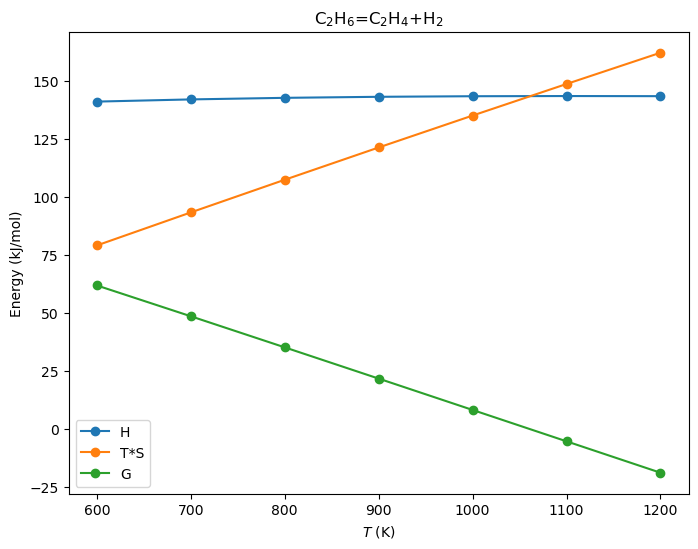

In [6]:
# Answer Here
idx = np.where(df.Subheader.str.contains("ETHYLENE", case=False, na=False))[0]
df_C2H4 = df.iloc[idx[0]:idx[-1]]
df_C2H4 = df_C2H4[(df_C2H4['T (K)'] >= 600) & (df_C2H4['T (K)'] <= 1200)]
idx = np.where(df.Subheader.str.contains("DIHYDROGEN", case=False, na=False))[0]
df_H2 = df.iloc[idx[0]:idx[-1]]
df_H2 = df_H2[(df_H2['T (K)'] >= 600) & (df_H2['T (K)'] <= 1200)]

# Standard state reaction enthalpy vs T, C2H6 = C2H4 + H2
plt.figure(figsize=(8,6))
dH_C2H6_C2H4 = df_H2['∆Hf° (kJ/mol)'].values + df_C2H4['∆Hf° (kJ/mol)'].values  - df_ethane['∆Hf° (kJ/mol)'].values 
plt.plot(df_ethane['T (K)'], dH_C2H6_C2H4, 'o-', label = 'H')
dS_C2H6_C2H4 = df_H2['S° (J/mol K)'].values + df_C2H4['S° (J/mol K)'].values  - df_ethane['S° (J/mol K)'].values 
plt.plot(df_ethane['T (K)'], dS_C2H6_C2H4*df_ethane['T (K)'].values/1000, 'o-', label = 'T*S')
dG_C2H6_C2H4 = dH_C2H6_C2H4 - df_ethane['T (K)'].values * dS_C2H6_C2H4 / 1000
plt.plot(df_ethane['T (K)'], dG_C2H6_C2H4, 'o-', label = 'G')

# plt.xlim(600,1200)
# plt.ylim(140,)
plt.title('C$_2$H$_6$=C$_2$H$_4$+H$_2$')
plt.legend()
plt.xlabel('$T$ (K)')
plt.ylabel('Energy (kJ/mol)')
plt.show()

### Q1.7. What do the plots tell you about the conditions necessary to run this reaction thermally? About what contributes to the free energy change with $T$?

In [7]:
# Answer Here
# Get T with delta G = 0 with linear interpolation
# np.interp only works for monotonically increasing sample points. dG_C2H6_C2H4 was decreasing though.
T_G0 = np.interp(0,dG_C2H6_C2H4[::-1],df_ethane['T (K)'].values[::-1])
print ('Standard state delta G = 0 at {:.2f} K.'.format(T_G0))
print ('Plot tells us that increasing temperature favors products; ie, equilibrium extent of reaction increases with T.')
print ('A positive reaction entropy contributes to the free energy change with T.')

Standard state delta G = 0 at 1061.59 K.
Plot tells us that increasing temperature favors products; ie, equilibrium extent of reaction increases with T.
A positive reaction entropy contributes to the free energy change with T.


### Q1.8. Plot the free energy of the ethane to ethylene reaction vs ethane conversion at 800, 1000, and 1200K and 1 bar. Determine the equilibrium conversion of ethane at each temperature if this was the only reaction to occur.

$G (T,n_j) = \sum_j\mu(T)_jn_j$

$\mu_j(T) = \mu_{j}^{o}(T) + RT(\mathrm{ln}y_j+\mathrm{ln}P)$

$G (T,n_j) = \sum_j\mu_j^{o}(T)n_j + RT\sum_jn_j(\mathrm{ln}y_j+\mathrm{ln}P)$

$n_j =n_{j0} + \nu_j\xi$; $y_j=n_j/\sum n_j$

$G (T,\xi) =  \sum_j\mu_j^\circ(T)n_{j0} + \xi\sum\nu_j\mu_j^\circ(T) + RT\sum_jN_j(\mathrm{ln}y_j+\mathrm{ln}P)$

Normalize $G$ by $n_{\ce{C2H6,0}}$. Let $\xi'=\xi/n_{\ce{C2H6,0}}$ be a dimensionless advancement.

$G (T,\xi')/\ce{molC2H6} =  \sum_j\mu_j^{o}(T)y_{j0} + \xi'\sum\nu_j\mu_j^{o} + RT\sum_j\frac{n_j}{n_{\ce{C2H6,0}}}(\mathrm{ln}y_j+\mathrm{ln}P)$

$G (T,\xi') =  \sum_j\mu_j^\circ(T)y_{j0} + \xi'\Delta G_r^\circ(T) + RT\sum_j\frac{n_j}{n_{\ce{C2H6,0}}}(\mathrm{ln}y_j+\mathrm{ln}P)$


$G (T,\xi') =  \sum_j\mu_j^\circ(T)y_{j0} + \xi'\Delta G_r^\circ(T) + RT\sum_j(y_{j0} + \nu_j\xi')(\mathrm{ln}y_j+\mathrm{ln}P)$

Take $y_{\text{ethane},0) = 1$, $y_{ethylene,0} = y_{H2,0} = 0$

$$G (T,\xi') =  \mu_{\ce{C2H6}}^\circ(T) + \xi'\Delta G_r^\circ(T) + RT\sum_j(y_{j0} + \nu_j\xi')(\mathrm{ln}y_j+\mathrm{ln}P)$$

This G has a T dependent intercept that is the standard state free energy of ethane at the given T. That can be figured out from the Table above and is a decreasing function of T. For ease of visualization, one can subtract off this reference energy and normalize to RT to have all plots start at 0.
$$\overline{G}  = (G - \mu_{\ce{C2H6}}^{o})/RT =  \xi'\Delta G_r^o/RT + \sum_j(y_{j0} + \nu_j\xi')(\mathrm{ln}y_j+\mathrm{ln}P)$$

This is what is plotted below.


In [8]:
# Reaction: C2H6 = C2H4 + H2
# First define the free energy (see the note) as a function of dimensionless advancement
# G_bar = (G(xi,T,P) - y_C2H6_0*mu_C2H6_0)/RT = ksi*deltaG/R/T + (y_H2_0 + nu_H2*ksi)(lny_H2 + lnP) + (y_C2H4_0 + nu_C2H4*ksi)(lny_C2H4 + lnP) + (y_C2H6_0 - nu_C2H6*ksi)(lny_C2H6 + lnP)
# G is the free energy of the system. ksi is the dimensionless advancement.
# deltaG is the standard free energy, y is the fraction, nu is the stoichiometric coefficient and P is the total pressure.
def G_C2H6_C2H4_H2(ksi):
  global y_H2_0,y_C2H4_0,y_C2H6_0,nu_H2,nu_C2H4,nu_C2H6,P,deltaG,T,R
  y_H2 = (y_H2_0+ksi)/(1+ksi)
  y_C2H4 = (y_C2H4_0+ksi)/(1+ksi)
  y_C2H6 = (y_C2H6_0-ksi)/(1+ksi)
  G0xi = ksi*deltaG/R/T*1000
  Gxi_H2 = (y_H2_0 + nu_H2*ksi)*(np.log(y_H2) + np.log(P))
  Gxi_C2H4 = (y_C2H4_0 + nu_C2H4*ksi)*(np.log(y_C2H4) + np.log(P))
  Gxi_C2H6 = (y_C2H6_0 + nu_C2H6*ksi)*(np.log(y_C2H6) + np.log(P))
  G_bar = G0xi+Gxi_H2+Gxi_C2H4+Gxi_C2H6
  G = G_bar*R*T + df_ethane[df_ethane['T (K)']==T]['∆Gf° (kJ/mol)'].iloc[0]*1000 
  return G_bar

In [9]:
# Define y, P and nu for this reaction
R = 8.314
y_H2_0 = 0
y_C2H4_0 = 0
y_C2H6_0 = 1
P = 1
nu_H2 = 1
nu_C2H4 = 1
nu_C2H6 = -1

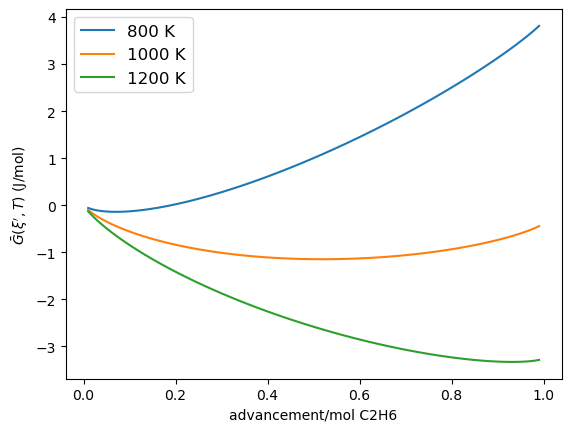

In [10]:
# First define an array of dimensionless advancement ksi. 
# N_C2H6 = N_C2H6_0 - N_C2H6_0*ksi. Conversion = (N_C2H6_0-N_C2H6)/N_C2H6_0 = ksi
ksi_array = np.arange(0.01,1,0.01)
conversion_array = ksi_array
T=800
deltaG = dG_C2H6_C2H4[df_ethane['T (K)'] == T][0] # Grab deltaG reaction from above
dG_reaction = G_C2H6_C2H4_H2(ksi_array)  # compute advancement part
plt.plot(conversion_array, dG_reaction, '-', label = '800 K')

T=1000
deltaG = dG_C2H6_C2H4[df_ethane['T (K)'] == T][0]
dG_reaction = G_C2H6_C2H4_H2(ksi_array)
plt.plot(conversion_array, dG_reaction, '-', label = '1000 K')

T=1200
deltaG = dG_C2H6_C2H4[df_ethane['T (K)'] == T][0]
dG_reaction = G_C2H6_C2H4_H2(ksi_array)
plt.plot(conversion_array, dG_reaction, '-', label = '1200 K')
# plt.xlim(600,1200)
# plt.ylim(-25,65)
plt.legend(fontsize=12)
plt.xlabel('advancement/mol C2H6')
plt.ylabel(r'$\bar{G}(\xi^\prime,T)$ (J/mol)')
plt.show()

### Q1.9. Imagine a semi-permeable membrane through which you could control the partial pressure (chemical potential) of hydrogen in a reaction vessel. Plot the mole fractions of ethane and ethylene as a function of $\ln P_{H_2}$ at 1000K. (Assume the H$_2$ does not contribute to the total moles in the vessel.)

**Reaction vessel conditions**

In a reaction vessel, the total volume is constant.  
For this reaction, the total pressure is also constant:

$$
P_{C_2H_6} + P_{C_2H_4} = P_{C_2H_6}^0
$$

Dividing through by $$ P_{C_2H_6}^0 $$:

$$
\frac{P_{C_2H_6}}{P_{C_2H_6}^0} + \frac{P_{C_2H_4}}{P_{C_2H_6}^0} = 1
$$

Define mole fractions:

$$
y_{C_2H_6} + y_{C_2H_4} = 1, 
\qquad y_{C_2H_4} = 1 - y_{C_2H_6}
$$

---

**Equilibrium constant:**

$$
K_{eq} = \frac{\left(\tfrac{P_{H_2}}{P^0}\right)\left(\tfrac{P_{C_2H_4}}{P^0}\right)}{\tfrac{P_{C_2H_6}}{P^0}}
= \frac{P_{H_2}}{P^0} \cdot \frac{P_{C_2H_4}/P_{C_2H_6}^0}{P_{C_2H_6}/P_{C_2H_6}^0}
$$

So:

$$
K_{eq} = \frac{P_{H_2}}{P^0} \cdot \frac{y_{C_2H_4}}{y_{C_2H_6}}
$$

Substitute $$ y_{C_2H_4} = 1 - y_{C_2H_6} $$:

$$
K_{eq} = \frac{P_{H_2}}{P^0} \cdot \frac{1 - y_{C_2H_6}}{y_{C_2H_6}}
$$

---

**Final expression:**

$$
y_{C_2H_6} = \frac{\tfrac{P_{H_2}}{P^0}}{\tfrac{P_{H_2}}{P^0} + K_{eq}}
$$

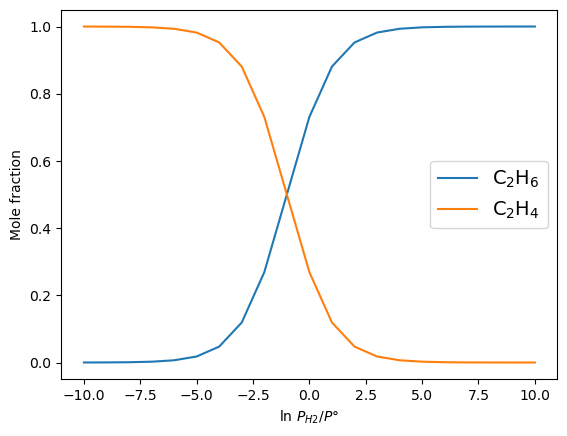

In [11]:
T=1000
deltaG = dG_C2H6_C2H4[df_ethane['T (K)'] == T][0]*1000 # kj/mol to j/mol
K_eq = np.exp(-deltaG/R/T)
ln_P_array = np.arange(-10,11,1)
P_H2_array = np.exp(ln_P_array)
y_C2H6_array = P_H2_array / (P_H2_array+K_eq)
plt.plot(ln_P_array,y_C2H6_array, '-', label = 'C$_2$H$_6$')
plt.plot(ln_P_array,1-y_C2H6_array, '-', label = 'C$_2$H$_4$')
plt.legend(fontsize=14)
plt.xlabel(r'ln $P_{H2}$/$P\degree$')
plt.ylabel(r'Mole fraction')
plt.show()

### Q1.10. Now consider both reactions simultaneously. Determine the equilibrium ratio of ethylene to acetylene, starting from pure ethane, at 1000 K and 1, 10, and 100 bar total pressure (again, assume ideal behavior at all conditions). Can you explain the result?

| | $C_2H_6$ | $C_2H_4$ |  $H_2$ | $C_2H_2$ |
| --- | --- | --- | --- | --- |
| Initial | 1 | 0 | 0 | 0 |
| Change  | $-\epsilon_1-\epsilon_2$ | $\epsilon_1$ | $\epsilon_1+2\epsilon_2$| $\epsilon_2$ |
| End | $1-\epsilon_1-\epsilon_2$ | $\epsilon_1$ |  $\epsilon_1+2\epsilon_2$ |$\epsilon_2$ |

$total = 1+\epsilon_1 + 2\epsilon_2$

Two equations:

$K_{eq1} = \frac{y_{C_2H_4}y_{H_2}}{y_{C_2H_6}}(\frac{P}{P^o}) = \frac{\frac{\epsilon_1}{1+\epsilon_1 + 2\epsilon_2}\frac{\epsilon_1+2\epsilon_2}{1+\epsilon_1 + 2\epsilon_2}}{\frac{1-\epsilon_1-\epsilon_2}{1+\epsilon_1 + 2\epsilon_2}}(\frac{P}{P^o}) = \frac{\epsilon_1(\epsilon_1+2\epsilon_2)}{(1+\epsilon_1 + 2\epsilon_2)(1-\epsilon_1-\epsilon_2)}(\frac{P}{P^o})$

$K_{eq2} = \frac{y_{C_2H_2}y_{H_2}^2}{y_{C_2H_6}}(\frac{P}{P^o})^2 = \frac{\epsilon_2(\epsilon_1+2\epsilon_2)^2}{(1+\epsilon_1 + 2\epsilon_2)^2(1-\epsilon_1-\epsilon_2)}(\frac{P}{P^o})^2$

solve for $\epsilon_1$ and $\epsilon_2$

In [12]:
# Calculate ∆Gf° for the first reaction

ethane_G = df['∆Gf° (kJ/mol)'][32:39]
hydrogen_G = df['∆Gf° (kJ/mol)'][46:53]
ethylene_G = df['∆Gf° (kJ/mol)'][18:25]

dG_r1 = hydrogen_G.values + ethylene_G.values - ethane_G.values
K_r1_1000K = np.exp(-dG_r1[4]/1000/0.008314)

In [13]:
# Calculate ∆Gf° for the second reaction
ethane_G = df['∆Gf° (kJ/mol)'][32:39]
hydrogen_G = df['∆Gf° (kJ/mol)'][46:53]
acetylene_G = df['∆Gf° (kJ/mol)'][18:25]

dG_r2_1000K = 2*df['∆Gf° (kJ/mol)'][50] + df['∆Gf° (kJ/mol)'][8] - df['∆Gf° (kJ/mol)'][36]

#Calculate Keq for second reaction
K_r2_1000K = np.exp(-dG_r2_1000K/1000/0.008314)

In [14]:
#solve for extension of reaction
from scipy.optimize import fsolve
# print(c1,c2)
def equations(p):
  c1 = K_r1_1000K/P
  c2 = K_r2_1000K/P**2
  e1,e2 = p
  return(e1*(e1+2*e2)-c1*(1+e1+2*e2)*(1-e1-e2),e2*(e1+2*e2)**2-c2*(1+e1+2*e2)**2*(1-e1-e2))
P = 1 #bar
e1,e2 =  fsolve(equations, (0.5,0.5))
print('Equilibirum ratio of ethane to acethlyene at 1 bar is ',e1/e2)
print (e1,e2)
P = 10
e1,e2 =  fsolve(equations, (0.5,0.5))
print('Equilibirum ratio of ethane to acethlyene at 10 bar is ',e1/e2)
print (e1,e2)

P = 100
e1,e2 =  fsolve(equations, (0.5,0.5))
print('Equilibirum ratio of ethane to acethlyene at 100 bar is ',e1/e2)
print (e1,e2)

print('As pressure increase, the conversion of second reaction decrease. \nThis is because the second reaction can produce more gas than the first reaction with same amount of ethane, the higher the pressure the more disfavor for second reaction. ')

Equilibirum ratio of ethane to acethlyene at 1 bar is  163.833896788789
0.5157785342538398 0.003148179615838412
Equilibirum ratio of ethane to acethlyene at 10 bar is  757.9113580419207
0.18810644660655823 0.00024819056293408115
Equilibirum ratio of ethane to acethlyene at 100 bar is  2727.1888957992073
0.060509373345017166 2.2187452229004765e-05
As pressure increase, the conversion of second reaction decrease. 
This is because the second reaction can produce more gas than the first reaction with same amount of ethane, the higher the pressure the more disfavor for second reaction. 


# NOx, NOx, who's there?
## A simple reaction of $\ce{NO}$ is it's oxidation to $\ce{NO2}$:

$\ce{NO(g) + O2(g) -> NO2(g)}$

## You can assume all gases behave ideally under the conditions considered in this problem.

source: https://webbook.nist.gov/cgi/cbook.cgi?ID=C10102439&Mask=1

### Q2.1. Determine $\Delta H^\circ(298~\text{K})$, $\Delta S^\circ(298~\text{K})$, $\Delta G^\circ(298~\text{K})$, and $K_p(298~\text{K})$ for the NO oxidation reaction (Don't forget to balance it first!). Be sure to specify your source and the standard state.

In [15]:
# Answer here
import numpy as np
import matplotlib.pyplot as plt
R = 8.314 #[=]J/molK
T = 298 #[=]K
H_rxn = 2*33.1-2*90.29-1*0 #[=]kJ/mol
S_rxn = 2*240.04-2*210.76-1*205.152 #[=]J/mol
G_rxn = H_rxn-T*S_rxn/1000
Kp = np.exp(-G_rxn*1000/(R*T))

In [16]:
print(f"∆H(298) = {H_rxn:.2f} kJ/mol")
print(f"∆S(298) = {S_rxn/1000:.2f} kJ/mol*K")
print(f"∆G(298) = {G_rxn:.2f} kJ/mol")
print(f"Kp = {Kp:.3g}")

∆H(298) = -114.38 kJ/mol
∆S(298) = -0.15 kJ/mol*K
∆G(298) = -70.70 kJ/mol
Kp = 2.47e+12


### Q2.2. Calculate the equilibrium partial pressure ratio of $\ce{NO2}$ to $\ce{NO}$ in the atmosphere near the surface of the earth. Assume the mixing ratio of $\ce{O2}$ to be 0.2 and a temperature of $25^\circ$C.

$$
K_p^\circ = \frac{p_{\mathrm{NO}_2}^2}{p_{\mathrm{NO}}^2 \, p_{\mathrm{O}_2}}
\;\;\;\;\;\;\Rightarrow\;\;\;\;\;\;
\frac{p_{\mathrm{NO}_2}}{p_{\mathrm{NO}}}
= \sqrt{K_p^\circ \, p_{\mathrm{O}_2}}
= \sqrt{(2.42 \times 10^{12})(0.2)}
$$

$$
= 6.96 \times 10^5
= \frac{p_{\mathrm{NO}_2}}{p_{\mathrm{NO}}}
$$

In [17]:
# Answer here
PO2 = 1*0.2
P_ratio = np.sqrt(Kp*PO2)
print(f'The pressure ratio is: {P_ratio:.3g}')

The pressure ratio is: 7.02e+05


### Q2.3. From standard compilations and at 1 atm standard state, $\Delta H^\circ(250~\mathrm{K}) = -116.532~\mathrm{kJ~mol^{-1}}$ and $\Delta S^\circ(250~\mathrm{K}) = -152.179~\mathrm{J/mol/K}$. Use the van't Hoff relationship to plot $\Delta G^\circ(T)$ vs $T$ from room temperature to $1000^\circ$C. Add a point on your plot for the $\Delta G^\circ(298~\mathrm{K})$ you found from a tabulation.

Van’t Hoff:

$$
\ln K_p = -\frac{\Delta G^\circ}{RT}
= -\frac{\Delta H^\circ}{R}\frac{1}{T} + \frac{\Delta S^\circ}{R}
$$

$$
\Delta G^\circ = \Delta H^\circ - T \Delta S^\circ
$$

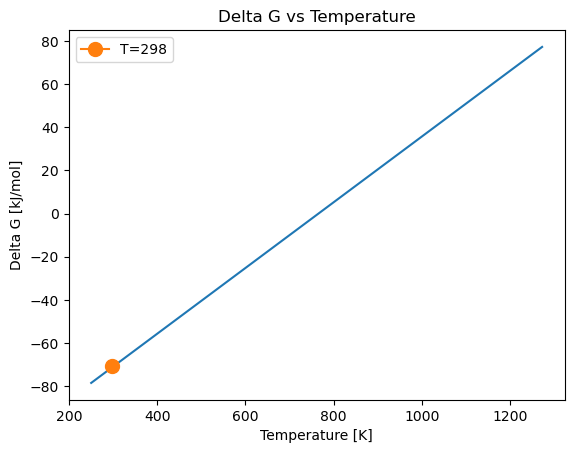

In [18]:
# Answer here
T = np.linspace(250, 1000+273, 100)
H = -116.532 # kj/mol
S = -152.179*10**-3 # kj/mol
G = H-T*S
plt.plot(T,G)
plt.plot(298, -70.65, marker='o',markersize=10,label='T=298')
plt.xlabel('Temperature [K]')
plt.ylabel('Delta G [kJ/mol]')
plt.title('Delta G vs Temperature')
plt.legend()

Van’t Hoff:

$$
\ln \frac{K_p(T_2)}{K_p^\circ}
= -\frac{\Delta H^\circ}{R}\left(\frac{1}{T_2} - \frac{1}{298}\right)
$$

$$
K_p(T_2) = K_p^\circ \exp\!\left[-\frac{\Delta H^\circ}{R}
\left(\frac{1}{T_2} - \frac{1}{298}\right)\right]
$$

$$
\Delta G(T) = -RT \ln\!\big(K_p(T)\big)
$$

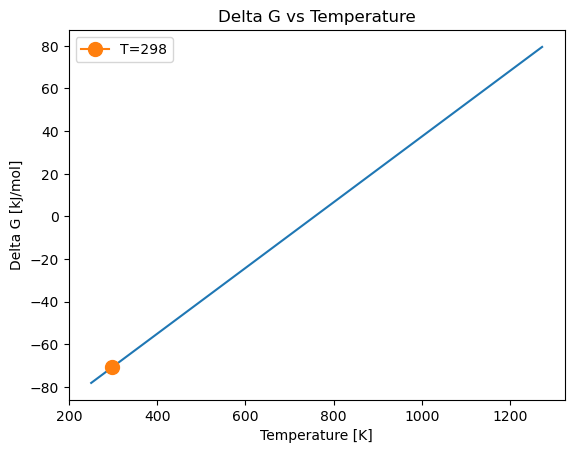

In [19]:
T = np.linspace(250, 1000+273, 100)
R = 8.314 * 10**-3 # kj/mol*K
H = -116.532 # kj/mol
Kp0 = 2.42*10**12 # from Q3.1
Kp = Kp0*np.exp(-H/R*(1/T-1/298))
G_T = -R*T*np.log(Kp)
plt.plot(T,G_T)
plt.plot(298, -70.65, marker='o',markersize=10,label='T=298')
plt.xlabel('Temperature [K]')
plt.ylabel('Delta G [kJ/mol]')
plt.title('Delta G vs Temperature')
plt.legend()

### Q2.4. NO oxidation is catalyzed over diesel oxidation catalysts (DOCs) on diesel vehicles. Plot the equilibrium conversion of $\ce{NO}$ to $\ce{NO2}$ vs $T$ from room temperature to $1000^\circ$C for an isobaric 1 atm reactor presented with 0.1% NO and 5% $\ce{O2}$, and balance $\ce{N2}$.

**Conversion relation**

$$
X_c = \frac{K(T)}{1 + K(T)}
$$

where

$$
K(T) = \exp\!\left(-\frac{\Delta H - T \Delta S}{R T}\right)
$$

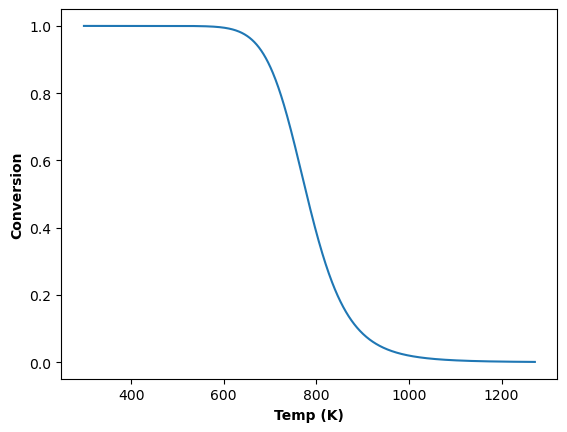

In [20]:
R = 8.314 # J/molK
H = -114.14 # kj/mol
S = -0.146538 # kj/mol
temp = np.arange(298,1273)
Kp_t = np.exp(-(H*1000-temp*S*1000)/(R*temp))
xc = Kp_t/(1+Kp_t)

plt.plot(temp,xc)
plt.xlabel('Temp (K)',weight='bold')
plt.ylabel('Conversion',weight='bold')
plt.show()